## Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import wandb

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.constants import EMOTION_LABELS, NUM_CLASSES, IMAGE_SIZE
from src.dataset import FER2013Dataset
from src.train_utils import (
    set_seed,
    get_device,
    count_parameters,
    train_one_epoch,
    evaluate,
)

## Configuration

In [2]:
CSV_PATH = PROJECT_ROOT / "data/raw/fer2013/fer2013.csv"

WANDB_ENTITY = "lkhiz23-free-university-of-tbilisi-"
WANDB_PROJECT = "facial-expression-recognition"

ENABLE_WANDB = True

IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

device = get_device()

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Data Loading

In [3]:
train_dataset = FER2013Dataset(CSV_PATH, split="Training")
val_dataset = FER2013Dataset(CSV_PATH, split="PublicTest")

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

image, label = train_dataset[0]
print("Single image shape:", image.shape)
print("Single label:", label.item())

Train samples: 28709
Validation samples: 3589
Single image shape: torch.Size([1, 48, 48])
Single label: 0


## MediumCNN Architecture

In [4]:
class MediumCNN(nn.Module):
    def __init__(self, dropout=0.3, num_classes=NUM_CLASSES):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),

                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),

                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(1, 32),      # 48 -> 24
            conv_block(32, 64),     # 24 -> 12
            conv_block(64, 128),    # 12 -> 6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model Sanity Check

In [5]:
set_seed(42)

model = MediumCNN(dropout=0.3).to(device)

print(model)
print("Trainable parameters:", count_parameters(model))

sample_images, sample_labels = next(
    iter(DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0))
)

sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

criterion = nn.CrossEntropyLoss()

sample_outputs = model(sample_images)
sample_loss = criterion(sample_outputs, sample_labels)

model.zero_grad()
sample_loss.backward()

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Loss:", sample_loss.item())
print("Backward pass: OK")

MediumCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride

## Simple Tensor Augmentation

In [6]:
class RandomHorizontalFlipTensor:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image):
        if torch.rand(1).item() < self.p:
            image = torch.flip(image, dims=[2])
        return image


def build_train_transform(augmentation):
    if augmentation == "none":
        return None

    if augmentation == "hflip":
        return RandomHorizontalFlipTensor(p=0.5)

    raise ValueError(f"Unknown augmentation: {augmentation}")

## Helper: small subset

In [7]:
def make_small_subset(dataset, size=50, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=size, replace=False)
    return Subset(dataset, indices.tolist())

##  Helper: plot history

In [8]:
def plot_history(history_df, run_name, sanity_check=False):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")

    if sanity_check:
        plt.plot(history_df["epoch"], history_df["small_data_loss"], label="Small Data Loss")
    else:
        plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{run_name} Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"{run_name}_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")

    if sanity_check:
        plt.plot(history_df["epoch"], history_df["small_data_accuracy"], label="Small Data Accuracy")
    else:
        plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{run_name} Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"{run_name}_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

## Training function for one W&B run

In [9]:
def run_medium_cnn_experiment(run_config):
    set_seed(run_config["seed"])

    run_name = run_config["run_name"]
    sanity_check = run_config["sanity_check"]

    train_transform = build_train_transform(run_config["augmentation"])

    current_train_dataset = FER2013Dataset(
        CSV_PATH,
        split="Training",
        transform=train_transform,
    )

    current_val_dataset = FER2013Dataset(
        CSV_PATH,
        split="PublicTest",
        transform=None,
    )

    if sanity_check:
        small_dataset = make_small_subset(
            current_train_dataset,
            size=run_config["small_data_size"],
            seed=run_config["seed"],
        )

        train_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    else:
        train_loader = DataLoader(
            current_train_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            current_val_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    model = MediumCNN(dropout=run_config["dropout"]).to(device)

    num_parameters = count_parameters(model)

    run_config["num_parameters"] = num_parameters
    run_config["device"] = device

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=run_config["learning_rate"],
        weight_decay=run_config["weight_decay"],
    )

    run = None

    if ENABLE_WANDB:
        run = wandb.init(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            name=run_name,
            config=run_config,
        )

    history = []

    best_val_accuracy = 0.0
    best_val_macro_f1 = 0.0
    best_small_data_accuracy = 0.0

    final_labels = None
    final_preds = None

    for epoch in range(1, run_config["epochs"] + 1):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        eval_loss, eval_metrics, eval_labels, eval_preds = evaluate(
            model,
            eval_loader,
            criterion,
            device,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
        }

        if sanity_check:
            best_small_data_accuracy = max(
                best_small_data_accuracy,
                eval_metrics["accuracy"],
            )

            row.update({
                "small_data_loss": eval_loss,
                "small_data_accuracy": eval_metrics["accuracy"],
                "small_data_macro_f1": eval_metrics["macro_f1"],
                "best_small_data_accuracy": best_small_data_accuracy,
            })

            print(
                f"{run_name} | Epoch {epoch:02d}/{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"small_loss={eval_loss:.4f} "
                f"small_acc={eval_metrics['accuracy']:.4f}",
                flush=True,
            )

        else:
            best_val_accuracy = max(best_val_accuracy, eval_metrics["accuracy"])
            best_val_macro_f1 = max(best_val_macro_f1, eval_metrics["macro_f1"])

            row.update({
                "val_loss": eval_loss,
                "val_accuracy": eval_metrics["accuracy"],
                "val_macro_f1": eval_metrics["macro_f1"],
                "best_val_accuracy": best_val_accuracy,
                "best_val_macro_f1": best_val_macro_f1,
            })

            print(
                f"{run_name} | Epoch {epoch:02d}/{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc={train_metrics['accuracy']:.4f} "
                f"train_f1={train_metrics['macro_f1']:.4f} | "
                f"val_loss={eval_loss:.4f} "
                f"val_acc={eval_metrics['accuracy']:.4f} "
                f"val_f1={eval_metrics['macro_f1']:.4f}",
                flush=True,
            )

        history.append(row)

        if ENABLE_WANDB:
            wandb.log(row, step=epoch)

        final_labels = eval_labels
        final_preds = eval_preds

    history_df = pd.DataFrame(history)

    plot_history(history_df, run_name, sanity_check=sanity_check)

    if ENABLE_WANDB:
        if not sanity_check:
            class_names = [EMOTION_LABELS[i] for i in range(NUM_CLASSES)]

            wandb.log({
                "validation_confusion_matrix": wandb.plot.confusion_matrix(
                    y_true=final_labels,
                    preds=final_preds,
                    class_names=class_names,
                )
            })

            run.summary["best_val_accuracy"] = best_val_accuracy
            run.summary["best_val_macro_f1"] = best_val_macro_f1

        else:
            run.summary["best_small_data_accuracy"] = best_small_data_accuracy

        run.summary["num_parameters"] = num_parameters
        run.finish()

    if sanity_check:
        result = {
            "run_name": run_name,
            "model": run_config["model_name"],
            "experiment_type": run_config["experiment_type"],
            "num_parameters": num_parameters,
            "best_small_data_accuracy": best_small_data_accuracy,
        }
    else:
        result = {
            "run_name": run_name,
            "model": run_config["model_name"],
            "experiment_type": run_config["experiment_type"],
            "learning_rate": run_config["learning_rate"],
            "dropout": run_config["dropout"],
            "weight_decay": run_config["weight_decay"],
            "augmentation": run_config["augmentation"],
            "num_parameters": num_parameters,
            "best_val_accuracy": best_val_accuracy,
            "best_val_macro_f1": best_val_macro_f1,
        }

    return result, history_df

## MediumCNN Run Configs

In [10]:
BASE_CONFIG = {
    "dataset": "FER2013",
    "model_name": "medium_cnn",
    "architecture_type": "cnn",
    "input_shape": "1x48x48",
    "normalization": "training_mean_std",
    "optimizer": "Adam",
    "seed": 42,
    "train_split": "Training",
    "val_split": "PublicTest",
}

In [11]:
MEDIUM_CNN_RUNS = [
    {
        **BASE_CONFIG,
        "run_name": "run_06_medium_cnn_small50_overfit",
        "experiment_type": "small_data_overfit_sanity_check",
        "sanity_check": True,
        "small_data_size": 50,
        "augmentation": "none",
        "dropout": 0.0,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 10,
        "epochs": 50,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_07_medium_cnn_baseline",
        "experiment_type": "baseline",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.0,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_08_medium_cnn_dropout_0_3",
        "experiment_type": "dropout_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.3,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_09_medium_cnn_dropout_0_5",
        "experiment_type": "dropout_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.5,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_10_medium_cnn_weight_decay_1e_4",
        "experiment_type": "weight_decay_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.3,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_11_medium_cnn_hflip",
        "experiment_type": "augmentation_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "hflip",
        "dropout": 0.3,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_12_medium_cnn_lr_3e_4",
        "experiment_type": "learning_rate_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.3,
        "learning_rate": 3e-4,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
]

## Choose Run Mode

In [12]:
RUN_MODE = "full"  # "sanity", "full", or "all"

if RUN_MODE == "sanity":
    SELECTED_RUNS = [MEDIUM_CNN_RUNS[0]]
elif RUN_MODE == "full":
    SELECTED_RUNS = MEDIUM_CNN_RUNS[1:]
elif RUN_MODE == "all":
    SELECTED_RUNS = MEDIUM_CNN_RUNS
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

print("Selected runs:")
for run_config in SELECTED_RUNS:
    print("-", run_config["run_name"])

Selected runs:
- run_07_medium_cnn_baseline
- run_08_medium_cnn_dropout_0_3
- run_09_medium_cnn_dropout_0_5
- run_10_medium_cnn_weight_decay_1e_4
- run_11_medium_cnn_hflip
- run_12_medium_cnn_lr_3e_4


## Run selected MediumCNN Experiments

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


run_07_medium_cnn_baseline | Epoch 01/15 | train_loss=1.5991 train_acc=0.3729 train_f1=0.2841 | val_loss=1.3950 val_acc=0.4622 val_f1=0.3797


run_07_medium_cnn_baseline | Epoch 02/15 | train_loss=1.2657 train_acc=0.5131 train_f1=0.4223 | val_loss=1.2107 val_acc=0.5286 val_f1=0.4392


run_07_medium_cnn_baseline | Epoch 03/15 | train_loss=1.1231 train_acc=0.5702 train_f1=0.4879 | val_loss=1.1424 val_acc=0.5673 val_f1=0.4968


run_07_medium_cnn_baseline | Epoch 04/15 | train_loss=1.0366 train_acc=0.6039 train_f1=0.5440 | val_loss=1.1110 val_acc=0.5829 val_f1=0.5398


...

run_07_medium_cnn_baseline | Epoch 11/15 | train_loss=0.4513 train_acc=0.8376 train_f1=0.8342 | val_loss=1.2562 val_acc=0.6063 val_f1=0.5834


run_07_medium_cnn_baseline | Epoch 12/15 | train_loss=0.3556 train_acc=0.8726 train_f1=0.8667 | val_loss=1.4617 val_acc=0.6046 val_f1=0.5808


run_07_medium_cnn_baseline | Epoch 13/15 | train_loss=0.2745 train_acc=0.9025 train_f1=0.9003 | val_loss=1.6045 val_acc=0.6066 val_f1=0.5806


run_07_medium_cnn_baseline | Epoch 14/15 | train_loss=0.2036 train_acc=0.9311 train_f1=0.9310 | val_loss=1.7010 val_acc=0.6211 val_f1=0.5974


run_07_medium_cnn_baseline | Epoch 15/15 | train_loss=0.1537 train_acc=0.9488 train_f1=0.9475 | val_loss=1.8584 val_acc=0.6099 val_f1=0.5923


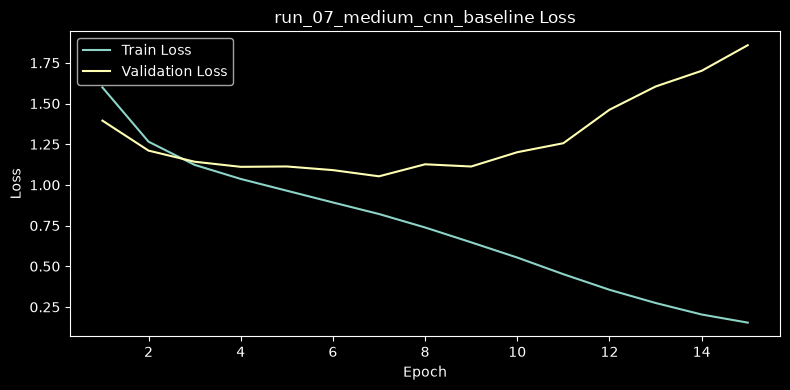

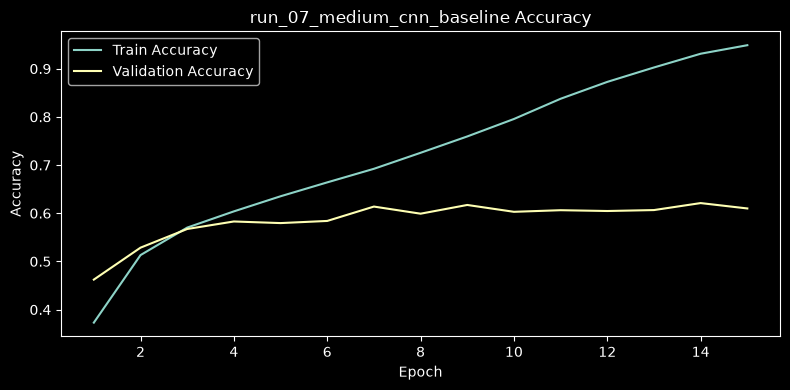

best_val_accuracy,▁▄▆▆▆▆█████████
best_val_macro_f1,▁▃▅▆▆▆█████████
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▃▄▄▅▅▅▆▆▇▇▇██
train_loss,█▆▆▅▅▅▄▄▃▃▂▂▂▁▁
train_macro_f1,▁▂▃▄▄▅▅▅▆▆▇▇███
val_accuracy,▁▄▆▆▆▆█▇█▇▇▇▇██
val_loss,▄▂▂▂▂▁▁▂▂▂▃▅▆▇█
val_macro_f1,▁▃▅▆▅▆█▇█▇█▇▇██
best_val_accuracy,0.62106
best_val_macro_f1,0.59854


run_08_medium_cnn_dropout_0_3 | Epoch 01/15 | train_loss=1.6628 train_acc=0.3440 train_f1=0.2478 | val_loss=1.4232 val_acc=0.4386 val_f1=0.3319


run_08_medium_cnn_dropout_0_3 | Epoch 02/15 | train_loss=1.3649 train_acc=0.4728 train_f1=0.3675 | val_loss=1.3105 val_acc=0.4904 val_f1=0.3770


run_08_medium_cnn_dropout_0_3 | Epoch 03/15 | train_loss=1.2500 train_acc=0.5212 train_f1=0.4170 | val_loss=1.1952 val_acc=0.5442 val_f1=0.4445


run_08_medium_cnn_dropout_0_3 | Epoch 04/15 | train_loss=1.1731 train_acc=0.5495 train_f1=0.4429 | val_loss=1.1714 val_acc=0.5542 val_f1=0.4553


...

run_08_medium_cnn_dropout_0_3 | Epoch 11/15 | train_loss=0.7658 train_acc=0.7075 train_f1=0.6445 | val_loss=1.0653 val_acc=0.6147 val_f1=0.5659


run_08_medium_cnn_dropout_0_3 | Epoch 12/15 | train_loss=0.7024 train_acc=0.7342 train_f1=0.6756 | val_loss=1.1116 val_acc=0.6102 val_f1=0.5760


run_08_medium_cnn_dropout_0_3 | Epoch 13/15 | train_loss=0.6291 train_acc=0.7592 train_f1=0.7145 | val_loss=1.2206 val_acc=0.6085 val_f1=0.5665


run_08_medium_cnn_dropout_0_3 | Epoch 14/15 | train_loss=0.5690 train_acc=0.7825 train_f1=0.7349 | val_loss=1.2012 val_acc=0.6113 val_f1=0.5635


run_08_medium_cnn_dropout_0_3 | Epoch 15/15 | train_loss=0.5117 train_acc=0.8042 train_f1=0.7672 | val_loss=1.3019 val_acc=0.6197 val_f1=0.5812


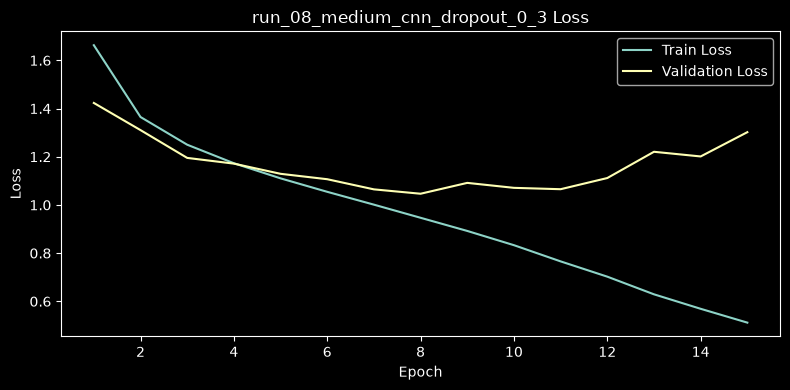

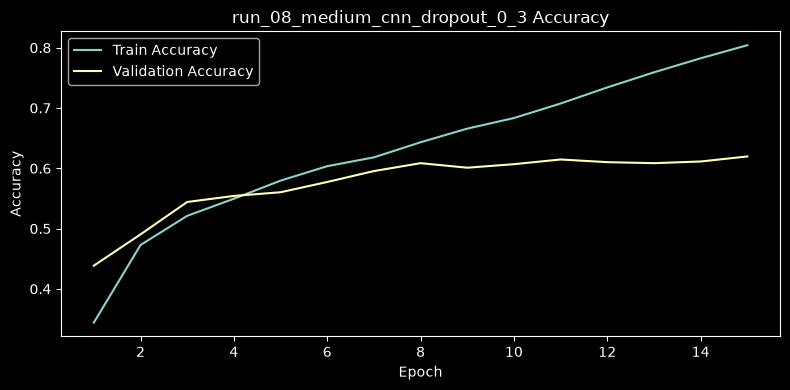

best_val_accuracy,▁▃▅▅▆▆▇████████
best_val_macro_f1,▁▂▄▄▄▅▆▇▇▇█████
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▄▄▅▅▅▆▆▆▇▇▇██
train_loss,█▆▅▅▅▄▄▄▃▃▃▂▂▁▁
train_macro_f1,▁▃▃▄▄▅▅▅▆▆▆▇▇██
val_accuracy,▁▃▅▅▆▆▇█▇██████
val_loss,█▆▄▃▃▂▁▁▂▁▁▂▄▄▆
val_macro_f1,▁▂▄▄▄▅▆▇▇▇█████
best_val_accuracy,0.61967
best_val_macro_f1,0.58124


run_09_medium_cnn_dropout_0_5 | Epoch 01/15 | train_loss=1.7501 train_acc=0.3014 train_f1=0.2084 | val_loss=1.5007 val_acc=0.4207 val_f1=0.2998


run_09_medium_cnn_dropout_0_5 | Epoch 02/15 | train_loss=1.4938 train_acc=0.4150 train_f1=0.3008 | val_loss=1.3489 val_acc=0.4795 val_f1=0.3341


run_09_medium_cnn_dropout_0_5 | Epoch 03/15 | train_loss=1.3960 train_acc=0.4519 train_f1=0.3475 | val_loss=1.2965 val_acc=0.4974 val_f1=0.3791


run_09_medium_cnn_dropout_0_5 | Epoch 04/15 | train_loss=1.3240 train_acc=0.4826 train_f1=0.3795 | val_loss=1.2260 val_acc=0.5341 val_f1=0.4311


...

run_09_medium_cnn_dropout_0_5 | Epoch 11/15 | train_loss=1.0432 train_acc=0.5950 train_f1=0.4876 | val_loss=1.0946 val_acc=0.5868 val_f1=0.4866


run_09_medium_cnn_dropout_0_5 | Epoch 12/15 | train_loss=0.9991 train_acc=0.6119 train_f1=0.5050 | val_loss=1.0960 val_acc=0.5913 val_f1=0.4918


run_09_medium_cnn_dropout_0_5 | Epoch 13/15 | train_loss=0.9545 train_acc=0.6337 train_f1=0.5250 | val_loss=1.1251 val_acc=0.5918 val_f1=0.4882


run_09_medium_cnn_dropout_0_5 | Epoch 14/15 | train_loss=0.9141 train_acc=0.6468 train_f1=0.5386 | val_loss=1.1806 val_acc=0.5940 val_f1=0.4901


run_09_medium_cnn_dropout_0_5 | Epoch 15/15 | train_loss=0.8755 train_acc=0.6630 train_f1=0.5538 | val_loss=1.1373 val_acc=0.6032 val_f1=0.5055


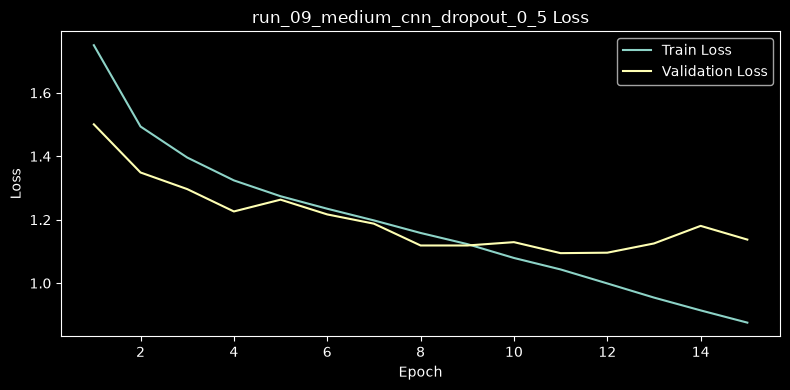

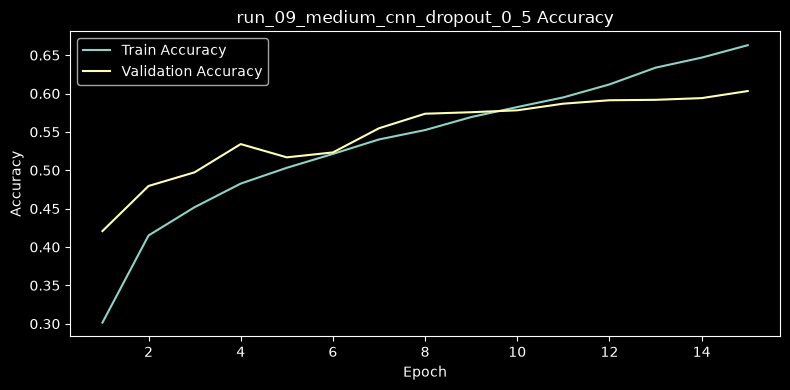

best_val_accuracy,▁▃▄▅▅▅▆▇▇▇▇████
best_val_macro_f1,▁▂▄▅▅▆▆▇▇▇▇████
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▄▅▅▅▆▆▆▆▇▇▇██
train_loss,█▆▅▅▄▄▄▃▃▃▂▂▂▁▁
train_macro_f1,▁▃▄▄▅▅▆▆▆▆▇▇▇██
val_accuracy,▁▃▄▅▅▅▆▇▇▇▇████
val_loss,█▅▄▃▄▃▃▁▁▂▁▁▂▂▂
val_macro_f1,▁▂▄▅▅▆▆▇▇▇▇█▇▇█
best_val_accuracy,0.60323
best_val_macro_f1,0.50553


run_10_medium_cnn_weight_decay_1e_4 | Epoch 01/15 | train_loss=1.7364 train_acc=0.3041 train_f1=0.2047 | val_loss=1.4754 val_acc=0.4246 val_f1=0.3153


run_10_medium_cnn_weight_decay_1e_4 | Epoch 02/15 | train_loss=1.4249 train_acc=0.4462 train_f1=0.3377 | val_loss=1.3071 val_acc=0.4926 val_f1=0.3766


run_10_medium_cnn_weight_decay_1e_4 | Epoch 03/15 | train_loss=1.2903 train_acc=0.5034 train_f1=0.3954 | val_loss=1.2301 val_acc=0.5333 val_f1=0.4248


run_10_medium_cnn_weight_decay_1e_4 | Epoch 04/15 | train_loss=1.2188 train_acc=0.5314 train_f1=0.4228 | val_loss=1.1892 val_acc=0.5350 val_f1=0.4420


...

run_10_medium_cnn_weight_decay_1e_4 | Epoch 11/15 | train_loss=0.8466 train_acc=0.6768 train_f1=0.5863 | val_loss=1.0857 val_acc=0.6016 val_f1=0.5600


run_10_medium_cnn_weight_decay_1e_4 | Epoch 12/15 | train_loss=0.7963 train_acc=0.6946 train_f1=0.6041 | val_loss=1.1304 val_acc=0.6071 val_f1=0.5289


run_10_medium_cnn_weight_decay_1e_4 | Epoch 13/15 | train_loss=0.7325 train_acc=0.7186 train_f1=0.6424 | val_loss=1.2377 val_acc=0.5993 val_f1=0.5191


run_10_medium_cnn_weight_decay_1e_4 | Epoch 14/15 | train_loss=0.6705 train_acc=0.7451 train_f1=0.6750 | val_loss=1.2847 val_acc=0.5968 val_f1=0.4996


run_10_medium_cnn_weight_decay_1e_4 | Epoch 15/15 | train_loss=0.6155 train_acc=0.7654 train_f1=0.7046 | val_loss=1.2483 val_acc=0.6124 val_f1=0.5698


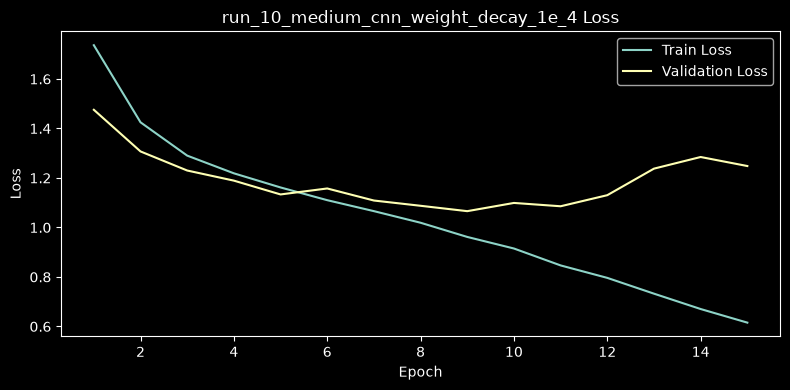

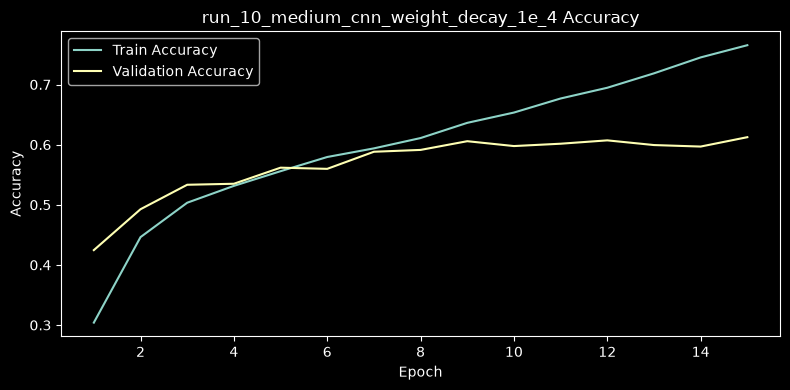

best_val_accuracy,▁▄▅▅▆▆▇▇███████
best_val_macro_f1,▁▃▄▄▅▅▆▆▆▆█████
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▄▄▅▅▅▆▆▆▇▇▇██
train_loss,█▆▅▅▄▄▄▄▃▃▂▂▂▁▁
train_macro_f1,▁▃▄▄▄▅▅▅▆▆▆▇▇██
val_accuracy,▁▄▅▅▆▆▇▇█▇███▇█
val_loss,█▅▄▃▂▃▂▁▁▂▁▂▄▅▄
val_macro_f1,▁▃▄▄▅▅▆▆▆▆█▇▇▆█
best_val_accuracy,0.61243
best_val_macro_f1,0.56979


run_11_medium_cnn_hflip | Epoch 01/15 | train_loss=1.6653 train_acc=0.3413 train_f1=0.2426 | val_loss=1.4098 val_acc=0.4567 val_f1=0.3467


run_11_medium_cnn_hflip | Epoch 02/15 | train_loss=1.3622 train_acc=0.4703 train_f1=0.3626 | val_loss=1.2700 val_acc=0.5132 val_f1=0.4005


run_11_medium_cnn_hflip | Epoch 03/15 | train_loss=1.2639 train_acc=0.5126 train_f1=0.4068 | val_loss=1.2031 val_acc=0.5263 val_f1=0.4123


run_11_medium_cnn_hflip | Epoch 04/15 | train_loss=1.2019 train_acc=0.5409 train_f1=0.4372 | val_loss=1.2406 val_acc=0.5227 val_f1=0.4372


...

run_11_medium_cnn_hflip | Epoch 11/15 | train_loss=0.9471 train_acc=0.6404 train_f1=0.5654 | val_loss=1.0721 val_acc=0.5952 val_f1=0.5375


run_11_medium_cnn_hflip | Epoch 12/15 | train_loss=0.9150 train_acc=0.6553 train_f1=0.5904 | val_loss=1.0468 val_acc=0.6119 val_f1=0.5644


run_11_medium_cnn_hflip | Epoch 13/15 | train_loss=0.8936 train_acc=0.6616 train_f1=0.5982 | val_loss=1.0361 val_acc=0.6244 val_f1=0.5680


run_11_medium_cnn_hflip | Epoch 14/15 | train_loss=0.8584 train_acc=0.6773 train_f1=0.6167 | val_loss=1.1188 val_acc=0.6110 val_f1=0.5381


run_11_medium_cnn_hflip | Epoch 15/15 | train_loss=0.8266 train_acc=0.6870 train_f1=0.6303 | val_loss=1.0558 val_acc=0.6211 val_f1=0.5855


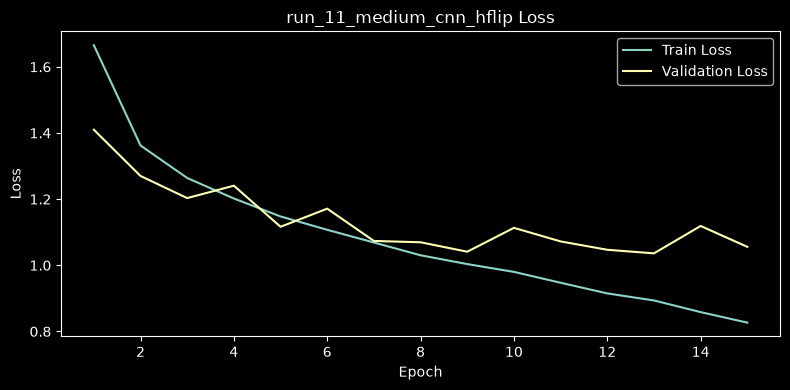

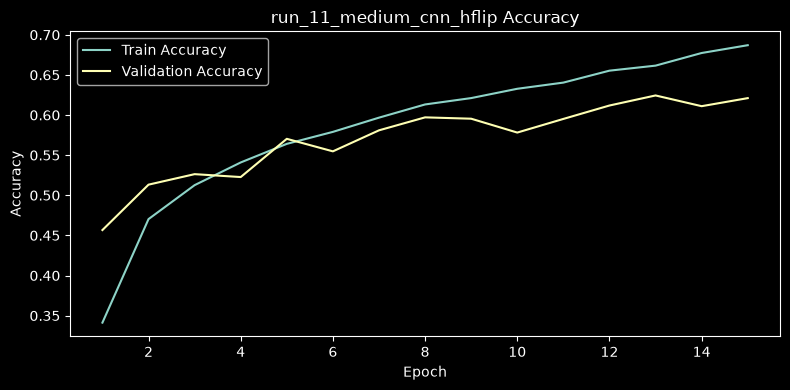

best_val_accuracy,▁▃▄▄▆▆▆▇▇▇▇▇███
best_val_macro_f1,▁▃▃▄▄▄▅▆▆▆▇▇▇▇█
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▄▅▆▆▆▇▇▇▇▇▇██
train_loss,█▅▅▄▄▃▃▃▂▂▂▂▂▁▁
train_macro_f1,▁▃▄▅▅▅▆▆▆▇▇▇▇██
val_accuracy,▁▃▄▄▆▅▆▇▇▆▇▇█▇█
val_loss,█▅▄▅▃▄▂▂▁▂▂▁▁▃▁
val_macro_f1,▁▃▃▄▄▄▅▆▆▆▇▇▇▇█
best_val_accuracy,0.62441
best_val_macro_f1,0.58553


run_12_medium_cnn_lr_3e_4 | Epoch 01/15 | train_loss=1.5259 train_acc=0.4036 train_f1=0.3091 | val_loss=1.3193 val_acc=0.4868 val_f1=0.3925


run_12_medium_cnn_lr_3e_4 | Epoch 02/15 | train_loss=1.2720 train_acc=0.5145 train_f1=0.4146 | val_loss=1.2042 val_acc=0.5252 val_f1=0.4189


run_12_medium_cnn_lr_3e_4 | Epoch 03/15 | train_loss=1.1545 train_acc=0.5605 train_f1=0.4577 | val_loss=1.1711 val_acc=0.5500 val_f1=0.4471


run_12_medium_cnn_lr_3e_4 | Epoch 04/15 | train_loss=1.0676 train_acc=0.5971 train_f1=0.5020 | val_loss=1.1090 val_acc=0.5734 val_f1=0.4812


...

run_12_medium_cnn_lr_3e_4 | Epoch 11/15 | train_loss=0.5530 train_acc=0.7959 train_f1=0.7624 | val_loss=1.2916 val_acc=0.5901 val_f1=0.5499


run_12_medium_cnn_lr_3e_4 | Epoch 12/15 | train_loss=0.4750 train_acc=0.8247 train_f1=0.7970 | val_loss=1.4081 val_acc=0.5779 val_f1=0.5456


run_12_medium_cnn_lr_3e_4 | Epoch 13/15 | train_loss=0.4019 train_acc=0.8528 train_f1=0.8296 | val_loss=1.4427 val_acc=0.5801 val_f1=0.5716


run_12_medium_cnn_lr_3e_4 | Epoch 14/15 | train_loss=0.3508 train_acc=0.8734 train_f1=0.8517 | val_loss=1.4564 val_acc=0.6010 val_f1=0.5825


run_12_medium_cnn_lr_3e_4 | Epoch 15/15 | train_loss=0.2885 train_acc=0.8976 train_f1=0.8790 | val_loss=1.6171 val_acc=0.5915 val_f1=0.5659


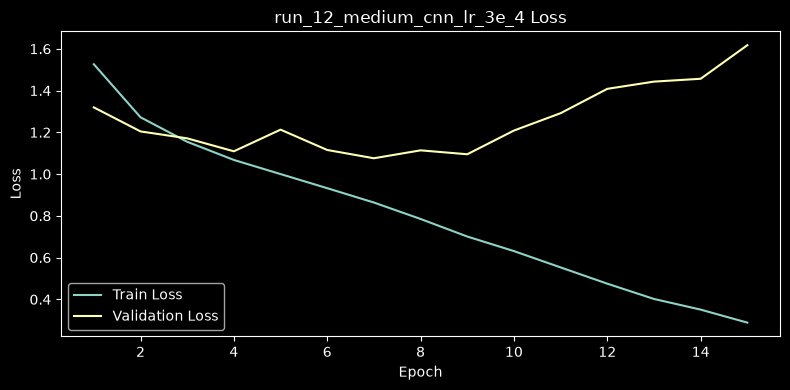

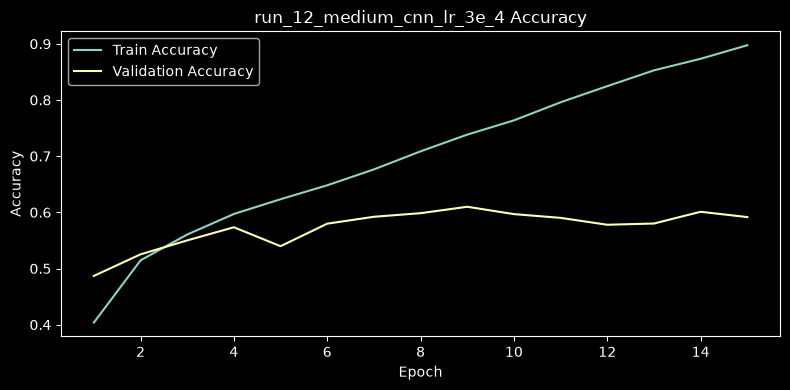

best_val_accuracy,▁▃▅▆▆▆▇▇███████
best_val_macro_f1,▁▂▃▄▅▆▇████████
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▃▄▄▄▅▅▆▆▇▇▇██
train_loss,█▇▆▅▅▅▄▄▃▃▂▂▂▁▁
train_macro_f1,▁▂▃▃▄▄▅▅▆▆▇▇▇██
val_accuracy,▁▃▅▆▄▆▇▇█▇▇▆▆▇▇
val_loss,▄▃▂▁▃▂▁▁▁▃▄▅▆▆█
val_macro_f1,▁▂▃▄▅▆▇███▇▇██▇
best_val_accuracy,0.60992
best_val_macro_f1,0.58245


,run_name,model,experiment_type,learning_rate,dropout,weight_decay,augmentation,num_parameters,best_val_accuracy,best_val_macro_f1
0,run_07_medium_cnn_baseline,medium_cnn,baseline,0.0010,0.0,0.0000,none,1469031,0.621064,0.598541
1,run_08_medium_cnn_dropout_0_3,medium_cnn,dropout_test,0.0010,0.3,0.0000,none,1469031,0.619671,0.581240
2,run_09_medium_cnn_dropout_0_5,medium_cnn,dropout_test,0.0010,0.5,0.0000,none,1469031,0.603232,0.505526
3,run_10_medium_cnn_weight_decay_1e_4,medium_cnn,weight_decay_test,0.0010,0.3,0.0001,none,1469031,0.612427,0.569794
4,run_11_medium_cnn_hflip,medium_cnn,augmentation_test,0.0010,0.3,0.0000,hflip,1469031,0.624408,0.585535
5,run_12_medium_cnn_lr_3e_4,medium_cnn,learning_rate_test,0.0003,0.3,0.0000,none,1469031,0.609919,0.582454


In [13]:
medium_cnn_results = []
medium_cnn_histories = {}

for run_config in SELECTED_RUNS:
    result, history_df = run_medium_cnn_experiment(run_config)

    medium_cnn_results.append(result)
    medium_cnn_histories[run_config["run_name"]] = history_df

medium_cnn_results_df = pd.DataFrame(medium_cnn_results)
medium_cnn_results_df

## Results

In [14]:
if "best_val_accuracy" in medium_cnn_results_df.columns:
    medium_cnn_results_df.sort_values("best_val_accuracy", ascending=False)
else:
    medium_cnn_results_df